<a href="https://colab.research.google.com/github/HieuStudyingCS/Learning-AI-Journey/blob/main/RegularizedRegression_MomentumGradientDescent_GradientDescent_PerformanceBenchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt
import math

In [ ]:
np.random.seed(42)
n_samples = 1000
n_feature = 1
X = 2 * np.random.rand(n_samples, n_feature)
X

array([[0.74908024],
       [1.90142861],
       [1.46398788],
       [1.19731697],
       [0.31203728],
       [0.31198904],
       [0.11616722],
       [1.73235229],
       [1.20223002],
       [1.41614516],
       [0.04116899],
       [1.9398197 ],
       [1.66488528],
       [0.42467822],
       [0.36364993],
       [0.36680902],
       [0.60848449],
       [1.04951286],
       [0.86389004],
       [0.58245828],
       [1.22370579],
       [0.27898772],
       [0.5842893 ],
       [0.73272369],
       [0.91213997],
       [1.57035192],
       [0.39934756],
       [1.02846888],
       [1.18482914],
       [0.09290083],
       [1.2150897 ],
       [0.34104825],
       [0.13010319],
       [1.89777107],
       [1.93126407],
       [1.6167947 ],
       [0.60922754],
       [0.19534423],
       [1.36846605],
       [0.88030499],
       [0.24407647],
       [0.99035382],
       [0.06877704],
       [1.8186408 ],
       [0.51755996],
       [1.32504457],
       [0.62342215],
       [1.040

In [ ]:
true_weight = 3.2
true_w0 = 1

In [ ]:
y = true_weight * X + true_w0 + np.random.randn(n_samples, 1)
y

array([[ 3.57475776],
       [ 5.7492272 ],
       [ 6.06495908],
       [ 5.44200004],
       [ 2.55830975],
       [ 3.07914566],
       [ 2.20565727],
       [ 7.00270741],
       [ 4.77697036],
       [ 3.87070356],
       [ 1.56135898],
       [ 7.41511074],
       [ 6.59921174],
       [ 1.08222173],
       [ 1.08262325],
       [ 3.22694172],
       [ 2.9075952 ],
       [ 5.03994186],
       [ 3.7927665 ],
       [ 2.89362264],
       [ 5.85414233],
       [ 1.37671598],
       [ 2.96584653],
       [ 2.88244051],
       [ 3.48435167],
       [ 5.71595403],
       [ 2.50004598],
       [ 3.81235178],
       [ 6.04720937],
       [ 0.40267534],
       [ 4.70141541],
       [ 1.65162333],
       [ 2.86330808],
       [ 7.26942221],
       [ 8.21188955],
       [ 4.68818265],
       [ 3.21657839],
       [ 2.51473233],
       [ 5.46137536],
       [ 4.88245633],
       [ 1.26375625],
       [ 5.57847966],
       [ 3.51898466],
       [ 6.45681201],
       [ 2.21068936],
       [ 6

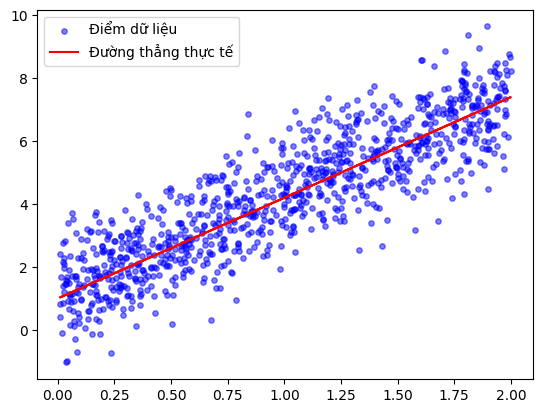

In [ ]:
plt.scatter(X, y, color='blue', alpha=0.5, s=15, label='Điểm dữ liệu')
plt.plot(X, true_weight * X+ true_w0, color='red', label='Đường thẳng thực tế')
plt.legend()
plt.show()

In [ ]:
class GradientDescent:
  def __init__(self, eta=0.01):
    self.eta = eta
    self.w = None
    self.w_0 = None
    self.loss_history = []
    self.nb_iterations = 0
    self.mae_history = []
    self.r2_score_history = []

  def mae(self, X, y, y_pred):
    return np.mean(np.abs(y_pred - y))

  def r2_score(self, X, y, y_pred):
    return 1 - np.sum((y_pred - y)**2) / np.sum((y - np.mean(y))**2)

  def loss_function(self, y_pred, y):
    return 0.5 * np.mean((y_pred - y)**2)

  def gradient(self, X, y, y_pred):
    N = X.shape[0]
    return (1 / N) * np.dot(X.T, y_pred - y)


  def fit(self, X, y):
    self.w = np.zeros((X.shape[1], 1))
    self.w_0 = 0

    for _ in range(100000):
      self.nb_iterations += 1

      y_pred = np.dot(X, self.w) + self.w_0

      loss = self.loss_function(y_pred, y)
      self.loss_history.append(loss)

      mae = self.mae(X, y, y_pred)
      self.mae_history.append(mae)

      r2 = self.r2_score(X, y, y_pred)
      self.r2_score_history.append(r2)

      if loss < 1e-6: break
      if len(self.loss_history) > 1 and abs(self.loss_history[-1] - self.loss_history[-2]) < 1e-10: break

      self.w -= self.eta * self.gradient(X, y, y_pred)
      self.w_0 -= self.eta * np.mean(y_pred - y)

    return self.nb_iterations, self.w, self.w_0, self.loss_history, self.mae_history, self.r2_score_history

  def predict(self, X):
    return X @ self.w + self.w_0


In [ ]:
class L2_RegularizedGradientDescent:
    def __init__(self, eta=0.01, alpha=0.01):
        self.eta = eta
        self.alpha = alpha
        self.w = None
        self.w_0 = None
        self.loss_history = []
        self.nb_iterations = 0
        self.mae_history = []
        self.r2_score_history = []

    def mae(self, y, y_pred):
        return np.mean(np.abs(y_pred - y))

    def r2_score(self, y, y_pred):
        return 1 - np.sum((y_pred - y)**2) / np.sum((y - np.mean(y))**2)

    def loss_function(self, y_pred, y):
        N = y.shape[0]
        return (1 / (2 * N)) * np.sum((y_pred - y)**2) + (self.alpha / (2 * N)) * np.sum(self.w**2)

    def gradient(self, X, y, y_pred):
        N = X.shape[0]
        return (1 / N) * np.dot(X.T, y_pred - y) + (self.alpha / N) * self.w

    def fit(self, X, y):
        self.w = np.zeros((X.shape[1], 1))
        self.w_0 = 0

        for _ in range(100000):
            self.nb_iterations += 1

            y_pred = np.dot(X, self.w) + self.w_0

            loss = self.loss_function(y_pred, y)
            self.loss_history.append(loss)

            mae = self.mae(y, y_pred)
            self.mae_history.append(mae)

            r2 = self.r2_score(y, y_pred)
            self.r2_score_history.append(r2)

            if loss < 1e-3: break
            if len(self.loss_history) > 1 and abs(self.loss_history[-1] - self.loss_history[-2]) < 1e-10: break

            self.w -= self.eta * self.gradient(X, y, y_pred)
            self.w_0 -= self.eta * np.mean(y_pred - y)

        return self.nb_iterations, self.w, self.w_0, self.loss_history, self.mae_history, self.r2_score_history

    def predict(self, X):
        return X @ self.w + self.w_0

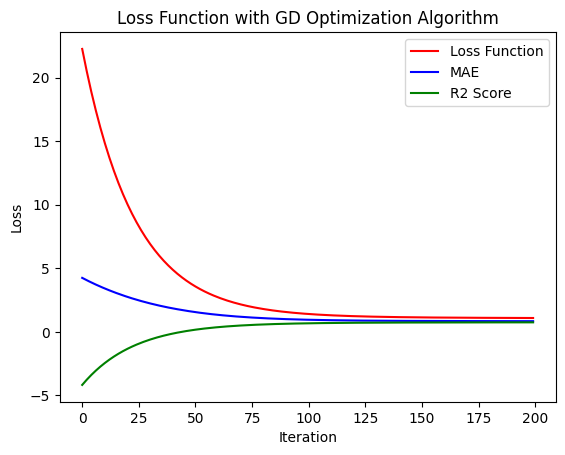

Time Execution 0.83391
The number of iterations: 4932
The weight: [[3.12231855]]
The bias: 1.1751170908787192


In [ ]:
model_GD = GradientDescent(eta=0.01)
start = time.time()
nb_iters, w, w_0, loss_history_GD, mae_history, r2_score_history = model_GD.fit(X, y)
end = time.time()

plt.plot(loss_history_GD[:200], color='red', label='Loss Function')
plt.plot(mae_history[:200], color='blue', label='MAE')
plt.plot(r2_score_history[:200], color='green', label='R2 Score')
plt.title('Loss Function with GD Optimization Algorithm')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.show()
print(f'Time Execution {end - start:.5f}')
print(f'The number of iterations: {nb_iters}')
print(f'The weight: {w}')
print(f'The bias: {w_0}')

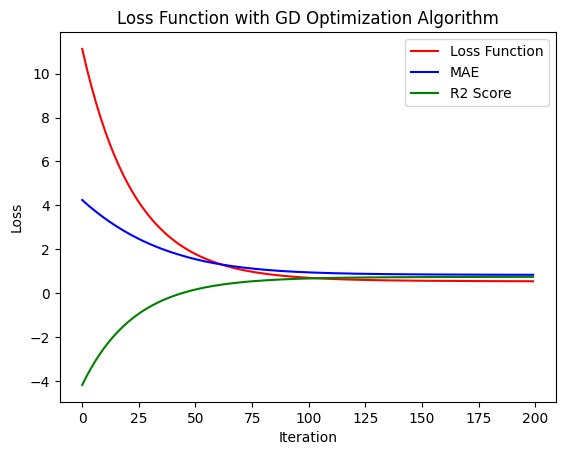

Time Execution 0.43845
The number of iterations: 4706
The weight: [[3.1176286]]
The bias: 1.1797377557913458


In [ ]:
model_L2 = L2_RegularizedGradientDescent(eta=0.01, alpha=0.5)
start_new = time.time()
nb_iters_RGD, w_RGD, w0_RGD, loss_history_GD_L2, mae_history_L2, r2_score_history_L2 = model_L2.fit(X, y)
end_new = time.time()

plt.plot(loss_history_GD_L2[:200], color='red', label='Loss Function')
plt.plot(mae_history_L2[:200], color='blue', label='MAE')
plt.plot(r2_score_history_L2[:200], color='green', label='R2 Score')
plt.title('Loss Function with GD Optimization Algorithm')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.show()
print(f'Time Execution {end_new - start_new:.5f}')
print(f'The number of iterations: {nb_iters_RGD}')
print(f'The weight: {w_RGD}')
print(f'The bias: {w0_RGD}')

In [ ]:
class MomentumGradientDescent:
  def __init__(self, eta=0.001, gamma=0.9):
    self.eta = eta
    self.gamma = gamma
    self.nb_iterations = 0
    self.loss_history, self.r2_score_history, self.mae_history = [], [], []
    self.w = None
    self.w_0 = None
    self.v_w0 = None
    self.v = None

  def loss_function(self, y_pred, y):
    N = y.shape[0]
    return (1 / (2 * N)) * np.sum((y_pred - y)**2)

  def mae(self, y, y_pred):
      return np.mean(np.abs(y_pred - y))

  def r2_score(self, y, y_pred):
      return 1 - np.sum((y_pred - y)**2) / np.sum((y - np.mean(y))**2)

  def gradient(self, X, y, y_pred):
    N = X.shape[0]
    return (1 / N) * np.dot(X.T, y_pred - y)

  def fit(self, X, y):
    self.w = np.zeros((X.shape[1], 1))
    self.w_0 = 0
    self.v = np.zeros((X.shape[1], 1))
    self.v_w0 = 0

    for _ in range(100000):
      self.nb_iterations += 1

      y_pred = np.dot(X, self.w) + self.w_0

      loss = self.loss_function(y_pred, y)
      self.loss_history.append(loss)

      mae = self.mae(y, y_pred)
      self.mae_history.append(mae)

      r2 = self.r2_score(y, y_pred)
      self.r2_score_history.append(r2)

      if loss < 1e-3: break
      if len(self.loss_history) > 1 and abs(self.loss_history[-1] - self.loss_history[-2]) < 1e-10: break

      self.v = self.v * self.gamma + self.eta * self.gradient(X, y, y_pred)
      self.v_w0 = self.gamma * self.v_w0 + self.eta * np.mean(y_pred - y)
      self.w -= self.v
      self.w_0 -= self.v_w0

    return self.nb_iterations, self.w, self.w_0, self.loss_history, self.mae_history, self.r2_score_history, self.v

  def predict(self, X):
    return X @ self.w + self.w_0

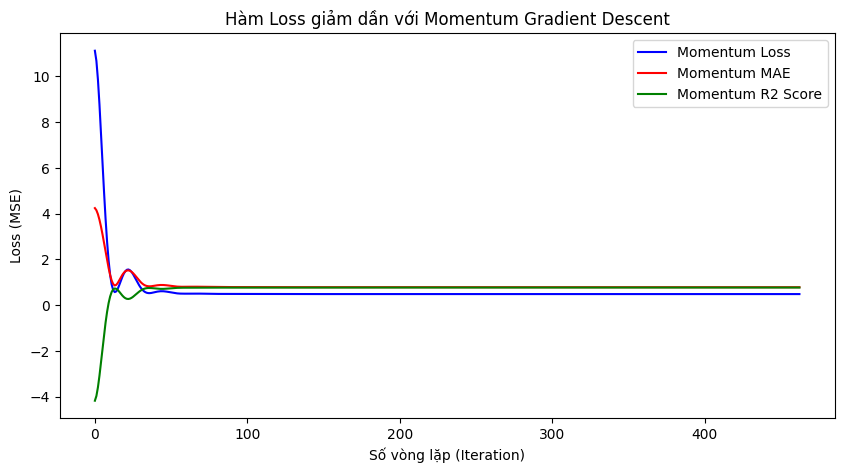

Thời gian chạy: 0.04731 giây
R2 Score cuối cùng: 0.7733
The number of iterations: 463
The weight: [[3.12249286]]
The bias: 1.1749138431976083


In [ ]:
model_momentum = MomentumGradientDescent(eta=0.01, gamma=0.9)
start = time.time()
nb_iters_m, w_m, w_0_m, loss_hist_m, mae_hist_m, r2_hist_m, _ = model_momentum.fit(X, y)
end = time.time()



plt.figure(figsize=(10, 5))
plt.plot(loss_hist_m, color='blue', label='Momentum Loss')
plt.plot(mae_hist_m, color='red', label='Momentum MAE')
plt.plot(r2_hist_m, color='green', label='Momentum R2 Score')
plt.title('Hàm Loss giảm dần với Momentum Gradient Descent')
plt.xlabel('Số vòng lặp (Iteration)')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

print(f"Thời gian chạy: {end - start:.5f} giây")
print(f"R2 Score cuối cùng: {r2_hist_m[-1]:.4f}")
print(f'The number of iterations: {nb_iters_m}')
print(f'The weight: {w_m}')
print(f'The bias: {w_0_m}')

In [ ]:
model_MGD = MomentumGradientDescent(eta=0.01, gamma=0.9)
model_L2 = L2_RegularizedGradientDescent(eta=0.01, alpha=0.5)
model_GD = GradientDescent(eta=0.01)

# Time Execution of GD
start_GD = time.time()
nb_iters_GD, w_GD, w0_GD, loss_history_GD, mae_history_GD, r2_score_history_GD = model_GD.fit(X, y)
end_GD = time.time()

# Time execution of MDG
start_MGD = time.time()
nb_iters_MGD, w_MGD, w0_MGD, loss_history_MGD, mae_history_MGD, r2_score_history_MGD, v_history = model_MGD.fit(X, y)
end_MGD = time.time()

# Time execution of L2
start_L2 = time.time()
nb_iters_L2, w_L2, w0_L2, loss_history_L2, mae_history_L2, r2_score_history_L2 = model_L2.fit(X, y)
end_L2 = time.time()

print(f'Time Execution of GD: {end_GD - start_GD:.5f}')
print(f'Time Execution of MDG: {end_MGD - start_MGD:.5f}')
print(f'Time Execution of L2: {end_L2 - start_L2:.5f}')

Time Execution of GD: 0.41236
Time Execution of MDG: 0.05846
Time Execution of L2: 0.40516
